In [26]:
import matplotlib.pyplot as plt
import numpy as np
import os
import librosa

highbass_sample_file = './highbass.mp3'
nobass_sample_file = './nobass.mp3'

def melspect(path, title, **kwargs):
    y, sr = librosa.load(path)
    mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, **kwargs)
    mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
    fig, ax = plt.subplots()
    img = librosa.display.specshow(mel_spect, x_axis='time', y_axis='mel', ax=ax)
#    ax.set(title=path.split('/')[-1])
    ax.set(title=title)
#    fig.colorbar(img, ax=ax, format="%+2.f dB")
#    fig.savefig('./images/' + path.split('/')[-1] + '.png')
#    plt.close(fig)

def spectrogram(path, fmax):
    y, sr = librosa.load(path)
    # Generate the spectrogram
    S = librosa.stft(y)
    D = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    # Get frequency components
    frequencies = librosa.fft_frequencies(sr=sr)
    # Filter out frequencies above 60 Hz
    D_filtered = D[frequencies <= fmax, :]
    # Plot
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(D_filtered, sr=sr, x_axis='time', y_axis='linear')
    plt.title(f"{path} - <= {fmax} Hz")
    plt.show()

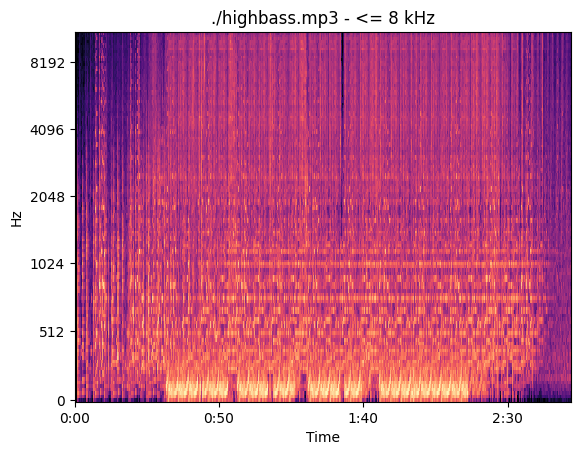

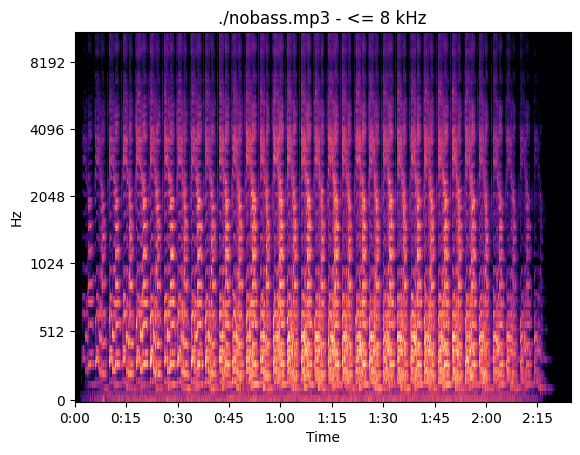

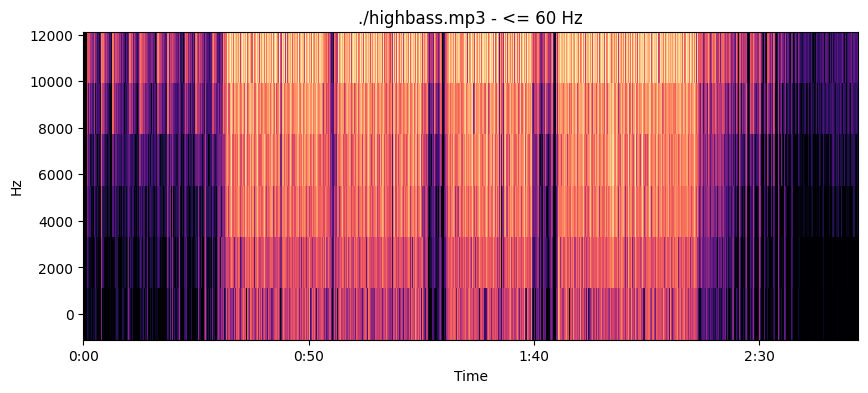

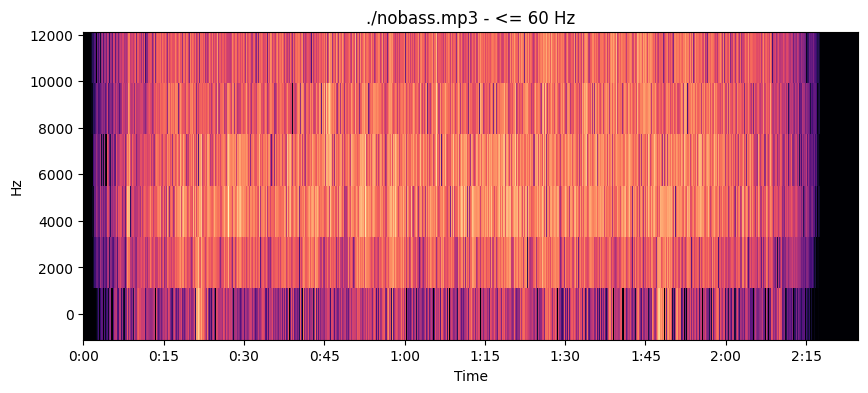

In [28]:
melspect(highbass_sample_file, title=highbass_sample_file + ' - <= 8 kHz', fmin=0, fmax=8000)
melspect(nobass_sample_file, title=nobass_sample_file + ' - <= 8 kHz', fmin=0, fmax=8000)
spectrogram(highbass_sample_file, 60)
spectrogram(nobass_sample_file, 60)

In [ ]:
y, sr = librosa.load(highbass_sample_file)
# Generate the spectrogram
S = librosa.stft(y)
S